In [1]:
import sys
import pandas as pd
import comtradeapicall

print(sys.executable)
print("pandas:", pd.__version__)

./.venv/Scripts/python.exe
pandas: 3.0.5


In [2]:
df_test = comtradeapicall.previewFinalData(
    typeCode="C",
    freqCode="M",
    clCode="HS",
    period="202401",
    reporterCode="156",
    cmdCode="850760",
    flowCode="X",
    partnerCode="0",
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

df_test

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,M,20240101,2024,1,202401,156,CHN,China,X,...,2.028849e+08,True,0.0,False,None,5.015674e+09,5.015674e+09,4,False,True


In [3]:
df_partners = comtradeapicall.previewFinalData(
    typeCode="C",
    freqCode="M",
    clCode="HS",
    period="202401",
    reporterCode="156",
    cmdCode="850760",
    flowCode="X",
    partnerCode=None,
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

df_partners.shape

(169, 47)

In [4]:
df_partners.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,M,20240101,2024,1,202401,156,CHN,China,X,...,2.028849e+08,True,0.0,False,None,5.015674e+09,5.015674e+09,4,False,True
1,C,M,20240101,2024,1,202401,156,CHN,China,X,...,1.280000e+03,False,0.0,False,None,3.903200e+04,3.903200e+04,0,True,False
2,C,M,20240101,2024,1,202401,156,CHN,China,X,...,7.542000e+03,False,0.0,False,None,1.648340e+05,1.648340e+05,0,True,False
3,C,M,20240101,2024,1,202401,156,CHN,China,X,...,7.266000e+03,False,0.0,False,None,1.861650e+05,1.861650e+05,0,True,False
4,C,M,20240101,2024,1,202401,156,CHN,China,X,...,5.729200e+04,False,0.0,False,None,1.575128e+06,1.575128e+06,0,True,False


In [5]:
df_partners[
    [
        "period",
        "reporterDesc",
        "partnerCode",
        "partnerISO",
        "partnerDesc",
        "cmdCode",
        "flowCode",
        "primaryValue",
        "netWgt",
        "isNetWgtEstimated",
        "isReported",
        "isAggregate"
    ]
].head(10)

,period,reporterDesc,partnerCode,partnerISO,partnerDesc,cmdCode,flowCode,primaryValue,netWgt,isNetWgtEstimated,isReported,isAggregate
0,202401,China,0,W00,World,850760,X,5.015674e+09,2.028849e+08,True,False,True
1,202401,China,8,ALB,Albania,850760,X,3.903200e+04,1.280000e+03,False,True,False
2,202401,China,12,DZA,Algeria,850760,X,1.648340e+05,7.542000e+03,False,True,False
3,202401,China,24,AGO,Angola,850760,X,1.861650e+05,7.266000e+03,False,True,False
4,202401,China,32,ARG,Argentina,850760,X,1.575128e+06,5.729200e+04,False,True,False
5,202401,China,36,AUS,Australia,850760,X,5.732131e+07,2.855390e+06,False,True,False
6,202401,China,40,AUT,Austria,850760,X,3.853900e+06,1.080860e+05,False,True,False
7,202401,China,44,BHS,Bahamas,850760,X,1.493000e+04,6.210000e+02,False,True,False
8,202401,China,48,BHR,Bahrain,850760,X,1.665900e+04,6.400000e+02,False,True,False
9,202401,China,50,BGD,Bangladesh,850760,X,1.141416e+07,6.750990e+05,False,True,False


In [6]:
world_row = df_partners[
    df_partners["isAggregate"] == True
].copy()

partner_rows = df_partners[
    df_partners["isAggregate"] == False
].copy()

In [7]:
world_row[
    ["partnerDesc", "primaryValue", "isAggregate"]
]

,partnerDesc,primaryValue,isAggregate
0,World,5.015674e+09,True


In [8]:
partner_rows[
    ["partnerDesc", "primaryValue", "isAggregate"]
].head()

,partnerDesc,primaryValue,isAggregate
1,Albania,39032.0,False
2,Algeria,164834.0,False
3,Angola,186165.0,False
4,Argentina,1575128.0,False
5,Australia,57321309.0,False


In [9]:
world_value = world_row["primaryValue"].iloc[0]

world_value

np.float64(5015673531.0)

In [10]:
partner_value = partner_rows["primaryValue"].sum()

partner_value

np.float64(5015673531.0)

In [11]:
(partner_value - world_value) / world_value

np.float64(0.0)

In [12]:
top10 = (
    partner_rows[
        ["partnerDesc", "primaryValue"]
    ]
    .sort_values(
        "primaryValue",
        ascending=False
    )
    .head(10)
    .copy()
)

top10

,partnerDesc,primaryValue
161,USA,1.097558e+09
52,Germany,8.492201e+08
76,Rep. of Korea,3.472075e+08
137,Viet Nam,3.131188e+08
69,Italy,2.565466e+08
72,Japan,2.200294e+08
105,Netherlands,1.892140e+08
134,India,1.804106e+08
142,Spain,1.186377e+08
11,Belgium,1.129042e+08


In [13]:
top10["export_share"] = (
    top10["primaryValue"]
    / world_value
)

top10

,partnerDesc,primaryValue,export_share
161,USA,1.097558e+09,0.218826
52,Germany,8.492201e+08,0.169313
76,Rep. of Korea,3.472075e+08,0.069224
137,Viet Nam,3.131188e+08,0.062428
69,Italy,2.565466e+08,0.051149
72,Japan,2.200294e+08,0.043868
105,Netherlands,1.892140e+08,0.037725
134,India,1.804106e+08,0.035969
142,Spain,1.186377e+08,0.023653
11,Belgium,1.129042e+08,0.022510


In [14]:
# 2024 年 1 月，中国 HS850760 锂离子电池出口目的地存在比较明显的集中现象，前十大目的市场合计贡献约 73.5% 的出口额。

top10_share = top10["primaryValue"].sum() / world_value

top10_share

np.float64(0.7346663145488526)

In [15]:
periods = ",".join(
    f"{year}{month:02d}"
    for year in [2023, 2024]
    for month in range(1, 13)
)

periods

'202301,202302,202303,202304,202305,202306,202307,202308,202309,202310,202311,202312,202401,202402,202403,202404,202405,202406,202407,202408,202409,202410,202411,202412'

In [16]:
df_monthly_world = comtradeapicall._previewFinalData(
    typeCode="C",
    freqCode="M",
    clCode="HS",
    period=periods,
    reporterCode="156",
    cmdCode="850760",
    flowCode="X",
    partnerCode="0",
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

df_monthly_world.shape

(24, 47)

In [17]:
display(
df_monthly_world[
    ["period", "primaryValue"]
].sort_values("period")
)

print(df_monthly_world["period"].nunique())

,period,primaryValue
0,202301,5.642064e+09
0,202302,4.608612e+09
0,202303,5.726203e+09
0,202304,5.308123e+09
0,202305,5.526198e+09
0,202306,5.225234e+09
0,202307,5.005587e+09
0,202308,5.679694e+09
0,202309,5.882249e+09
0,202310,5.589979e+09


24


In [18]:
df_monthly_world.to_csv(
    "../data/raw/comtrade_china_850760_world_monthly_2023_2024.csv",
    index=False
)

In [19]:
# 然后建立真正的分析表

monthly_export = (
    df_monthly_world[
        [
            "period",
            "reporterDesc",
            "partnerDesc",
            "cmdCode",
            "cmdDesc",
            "primaryValue",
            "netWgt",
            "isNetWgtEstimated"
        ]
    ]
    .copy()
)

In [20]:
monthly_export = monthly_export.rename(
    columns={
        "reporterDesc": "exporter",
        "partnerDesc": "destination",
        "cmdCode": "hs_code",
        "cmdDesc": "product",
        "primaryValue": "export_value_usd",
        "netWgt": "net_weight_kg"
    }
)

In [21]:
# 把 202401 变成日期
monthly_export["month"] = pd.to_datetime(
    monthly_export["period"].astype(str),
    format="%Y%m"
)

In [22]:
monthly_export = (
    monthly_export
    .sort_values("month")
    .reset_index(drop=True)
)

In [23]:
monthly_export["export_value_billion_usd"] = (
    monthly_export["export_value_usd"] / 1e9
)

In [24]:
# 现在第一次做环比 MoM
monthly_export["mom"] = (
    monthly_export["export_value_usd"]
    .pct_change(fill_method=None)
)

In [25]:
# 再做同比 YoY
monthly_export["yoy"] = (
    monthly_export["export_value_usd"]
    .pct_change(periods=12, fill_method=None)
)

In [26]:
monthly_export[
    [
        "month",
        "export_value_billion_usd",
        "mom",
        "yoy"
    ]
]

,month,export_value_billion_usd,mom,yoy
0,2023-01-01,5.642064,NaN,NaN
1,2023-02-01,4.608612,-0.183169,NaN
2,2023-03-01,5.726203,0.242500,NaN
3,2023-04-01,5.308123,-0.073012,NaN
4,2023-05-01,5.526198,0.041083,NaN
5,2023-06-01,5.225234,-0.054461,NaN
6,2023-07-01,5.005587,-0.042036,NaN
7,2023-08-01,5.679694,0.134671,NaN
8,2023-09-01,5.882249,0.035663,NaN
9,2023-10-01,5.589979,-0.049687,NaN


In [27]:
display(
    monthly_export[
        [
            "month",
            "export_value_billion_usd",
            "mom",
            "yoy"
        ]
    ].style.format({
        "export_value_billion_usd": "{:.2f}",
        "mom": "{:.2%}",
        "yoy": "{:.2%}"
    })
)

,month,export_value_billion_usd,mom,yoy
0,2023-01-01 00:00:00,5.64,nan%,nan%
1,2023-02-01 00:00:00,4.61,-18.32%,nan%
2,2023-03-01 00:00:00,5.73,24.25%,nan%
3,2023-04-01 00:00:00,5.31,-7.30%,nan%
4,2023-05-01 00:00:00,5.53,4.11%,nan%
5,2023-06-01 00:00:00,5.23,-5.45%,nan%
6,2023-07-01 00:00:00,5.01,-4.20%,nan%
7,2023-08-01 00:00:00,5.68,13.47%,nan%
8,2023-09-01 00:00:00,5.88,3.57%,nan%
9,2023-10-01 00:00:00,5.59,-4.97%,nan%


In [28]:
monthly_export["ma3"] = (
    monthly_export["export_value_billion_usd"]
    .rolling(3)
    .mean()
)

monthly_export["ma3"]

0          NaN
1          NaN
2     5.325626
3     5.214313
4     5.520175
5     5.353185
6     5.252340
7     5.303505
8     5.522510
9     5.717307
10    5.667948
11    5.467477
12    5.276042
13    4.668633
14    4.399140
15    4.161093
16    4.470209
17    4.684238
18    5.034293
19    5.419194
20    5.480748
21    5.560243
22    5.561694
23    5.811515
Name: ma3, dtype: float64

In [29]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [30]:
import matplotlib.pyplot as plt

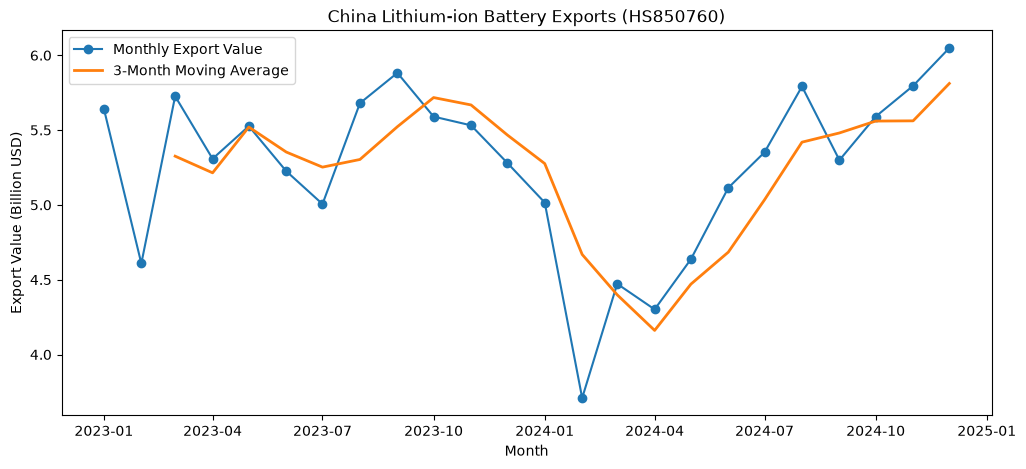

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_export["month"],
    monthly_export["export_value_billion_usd"],
    marker="o",
    label="Monthly Export Value"
)

plt.plot(
    monthly_export["month"],
    monthly_export["ma3"],
    linewidth=2,
    label="3-Month Moving Average"
)

plt.title("China Lithium-ion Battery Exports (HS850760)")
plt.xlabel("Month")
plt.ylabel("Export Value (Billion USD)")
plt.legend()

plt.show()

In [32]:
df_partner_monthly_raw = comtradeapicall._previewFinalData(
    typeCode="C",
    freqCode="M",
    clCode="HS",
    period=periods,
    reporterCode="156",
    cmdCode="850760",
    flowCode="X",
    partnerCode=None,
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

df_partner_monthly_raw.shape

(4218, 47)

In [33]:
print("rows:", len(df_partner_monthly_raw))
print("months:", df_partner_monthly_raw["period"].nunique())
print("partners:", df_partner_monthly_raw["partnerCode"].nunique())

rows: 4218
months: 24
partners: 207


In [34]:
df_partner_monthly_raw[
    ["period", "partnerCode", "partnerDesc", "primaryValue", "isAggregate"]
].head(10)

,period,partnerCode,partnerDesc,primaryValue,isAggregate
0,202301,0,World,5.642064e+09,True
1,202301,8,Albania,9.267000e+03,False
2,202301,12,Algeria,1.916905e+06,False
3,202301,24,Angola,5.183000e+03,False
4,202301,28,Antigua and Barbuda,1.119100e+04,False
5,202301,32,Argentina,2.783946e+06,False
6,202301,36,Australia,4.240164e+07,False
7,202301,40,Austria,1.766908e+07,False
8,202301,44,Bahamas,4.196700e+04,False
9,202301,48,Bahrain,4.968000e+03,False


In [35]:
df_partner_monthly_raw.duplicated(
    subset=["period", "partnerCode"]
).sum()

np.int64(0)

In [36]:
partner_monthly = (
    df_partner_monthly_raw[
        df_partner_monthly_raw["isAggregate"] == False
    ][
        [
            "period",
            "partnerCode",
            "partnerISO",
            "partnerDesc",
            "primaryValue"
        ]
    ]
    .copy()
)

In [37]:
partner_monthly = partner_monthly.rename(
    columns={
        "partnerCode": "destination_code",
        "partnerISO": "destination_iso",
        "partnerDesc": "destination",
        "primaryValue": "export_value_usd"
    }
)

In [38]:
partner_monthly["month"] = pd.to_datetime(
    partner_monthly["period"].astype(str),
    format="%Y%m"
)

In [39]:
partner_monthly["year"] = partner_monthly["month"].dt.year

In [40]:
# 第一次构建“国家市场表现表”
country_year_long = (
    partner_monthly
    .groupby(
        ["destination_code", "destination", "year"],
        as_index=False
    )["export_value_usd"]
    .sum()
)

In [41]:
country_year = (
    country_year_long
    .pivot(
        index=["destination_code", "destination"],
        columns="year",
        values="export_value_usd"
    )
    .reset_index()
)

country_year.head()

year,destination_code,destination,2023,2024
0,4,Afghanistan,2386507.0,2533001.0
1,8,Albania,719209.0,568342.0
2,12,Algeria,18573541.0,11727414.0
3,20,Andorra,67429.0,27409.0
4,24,Angola,2519493.0,2960042.0


In [42]:
country_year["growth_2024"] = (
    country_year[2024] / country_year[2023] - 1
)

In [43]:
total_2024 = country_year[2024].sum()

country_year["export_share_2024"] = (
    country_year[2024] / total_2024
)

In [44]:
country_year = country_year.sort_values(
    2024,
    ascending=False
)

In [45]:
country_year[
    [
        "destination",
        2023,
        2024,
        "growth_2024",
        "export_share_2024"
    ]
].head(15)

year,destination,2023,2024,growth_2024,export_share_2024
197,USA,1.356493e+10,1.533614e+10,0.130573,0.250890
66,Germany,9.335448e+09,1.025403e+10,0.098397,0.167750
91,Rep. of Korea,7.850430e+09,3.788156e+09,-0.517459,0.061972
167,Viet Nam,3.284245e+09,3.709584e+09,0.129509,0.060687
124,Netherlands,3.639931e+09,2.407020e+09,-0.338718,0.039377
87,Japan,2.426182e+09,2.327215e+09,-0.040791,0.038072
164,India,2.200897e+09,2.158380e+09,-0.019318,0.035310
195,United Kingdom,1.588374e+09,1.630276e+09,0.026381,0.026670
7,Australia,7.238254e+08,1.456511e+09,1.012240,0.023828
172,Spain,1.864473e+09,1.170300e+09,-0.372316,0.019145


In [46]:
country_year["export_increment_2024"] = (
    country_year[2024] - country_year[2023]
)

In [47]:
large_markets = (
    country_year[
        country_year[2024] >= 5e8
    ]
    .sort_values(
        "growth_2024",
        ascending=False
    )
)

In [48]:
large_markets[
    [
        "destination",
        2023,
        2024,
        "growth_2024",
        "export_increment_2024",
        "export_share_2024"
    ]
].head(20)

year,destination,2023,2024,growth_2024,export_increment_2024,export_share_2024
60,France,3.093476e+08,9.726030e+08,2.144046,6.632554e+08,0.015911
159,Saudi Arabia,2.604855e+08,6.882587e+08,1.642215,4.277732e+08,0.011260
7,Australia,7.238254e+08,1.456511e+09,1.012240,7.326852e+08,0.023828
181,Thailand,3.365160e+08,5.110949e+08,0.518783,1.745789e+08,0.008361
77,Hungary,5.336456e+08,7.342345e+08,0.375884,2.005888e+08,0.012012
59,Finland,5.193857e+08,7.081229e+08,0.363386,1.887372e+08,0.011584
113,"Other Asia, nes",6.047863e+08,6.856843e+08,0.133763,8.089799e+07,0.011217
197,USA,1.356493e+10,1.533614e+10,0.130573,1.771207e+09,0.250890
167,Viet Nam,3.284245e+09,3.709584e+09,0.129509,4.253387e+08,0.060687
66,Germany,9.335448e+09,1.025403e+10,0.098397,9.185787e+08,0.167750


In [49]:
country_year.columns.name = None

plot_df = country_year[
    (country_year[2023].notna())
    & (country_year[2024].notna())
    & (country_year[2024] >= 5e8)
    & (country_year["destination"] != "Other Asia, nes")
].copy()

plot_df["export_2024_billion"] = (
    plot_df[2024] / 1e9
)

plot_df["growth_pct"] = (
    plot_df["growth_2024"] * 100
)

In [50]:
size_cut = plot_df["export_2024_billion"].median()

size_cut

np.float64(1.070147269)

In [51]:
candidate_names = [
    "USA",
    "Germany",
    "Viet Nam",
    "France",
    "Saudi Arabia",
    "Australia"
]

candidates = (
    country_year[
        country_year["destination"].isin(candidate_names)
    ][
        [
            "destination_code",
            "destination",
            2023,
            2024,
            "growth_2024",
            "export_increment_2024",
            "export_share_2024"
        ]
    ]
    .copy()
)

candidates["export_2024_billion"] = (
    candidates[2024] / 1e9
)

candidates

,destination_code,destination,2023,2024,growth_2024,export_increment_2024,export_share_2024,export_2024_billion
197,842,USA,1.356493e+10,1.533614e+10,0.130573,1.771207e+09,0.250890,15.336139
66,276,Germany,9.335448e+09,1.025403e+10,0.098397,9.185787e+08,0.167750,10.254027
167,704,Viet Nam,3.284245e+09,3.709584e+09,0.129509,4.253387e+08,0.060687,3.709584
7,36,Australia,7.238254e+08,1.456511e+09,1.012240,7.326852e+08,0.023828,1.456511
60,251,France,3.093476e+08,9.726030e+08,2.144046,6.632554e+08,0.015911,0.972603
159,682,Saudi Arabia,2.604855e+08,6.882587e+08,1.642215,4.277732e+08,0.011260,0.688259


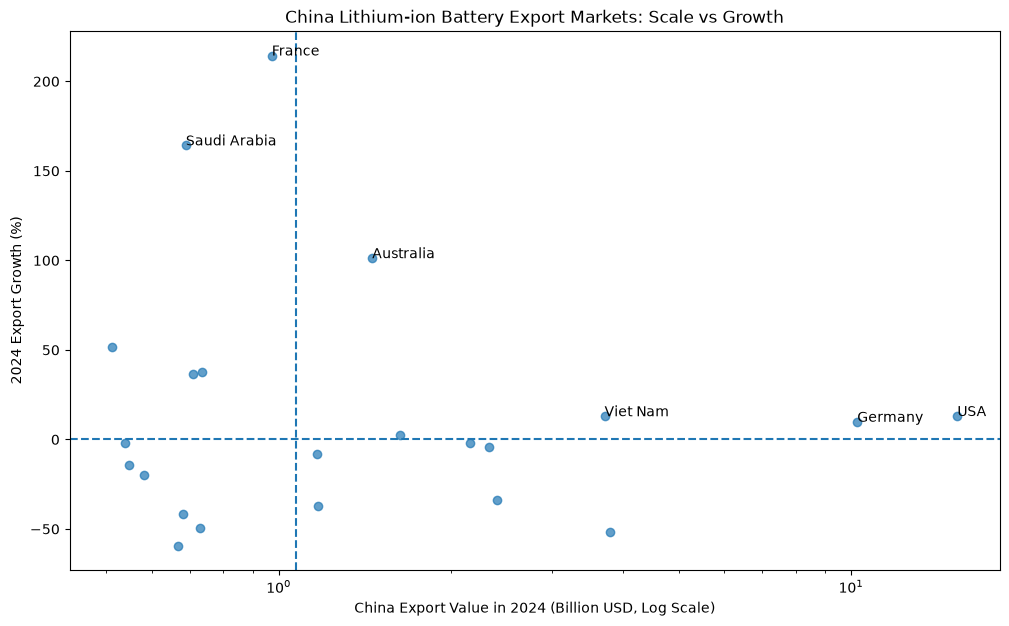

In [52]:
plt.figure(figsize=(12, 7))

plt.scatter(
    plot_df["export_2024_billion"],
    plot_df["growth_pct"],
    alpha=0.7
)

plt.xscale("log")

plt.axvline(
    size_cut,
    linestyle="--"
)

plt.axhline(
    0,
    linestyle="--"
)

for _, row in plot_df.iterrows():
    if row["destination"] in candidate_names:
        plt.annotate(
            row["destination"],
            (
                row["export_2024_billion"],
                row["growth_pct"]
            )
        )

plt.xlabel("China Export Value in 2024 (Billion USD, Log Scale)")
plt.ylabel("2024 Export Growth (%)")
plt.title("China Lithium-ion Battery Export Markets: Scale vs Growth")

plt.show()

In [53]:
import_tables = []

for _, row in candidates.iterrows():

    reporter_code = str(row["destination_code"])
    country = row["destination"]

    df_temp = comtradeapicall.previewFinalData(
        typeCode="C",
        freqCode="A",
        clCode="HS",
        period="2024",
        reporterCode=reporter_code,
        cmdCode="850760",
        flowCode="M",
        partnerCode=None,
        partner2Code=None,
        customsCode=None,
        motCode=None,
        maxRecords=500,
        format_output="JSON",
        aggregateBy=None,
        breakdownMode="classic",
        countOnly=None,
        includeDesc=True
    )

    if df_temp is not None:
        df_temp["market"] = country
        import_tables.append(df_temp)

In [54]:
import_raw = pd.concat(
    import_tables,
    ignore_index=True
)

import_raw.shape

(329, 48)

In [55]:
import_raw[
    [
        "market",
        "reporterDesc",
        "partnerDesc",
        "primaryValue",
        "isAggregate"
    ]
].head(20)

,market,reporterDesc,partnerDesc,primaryValue,isAggregate
0,USA,USA,World,2.384868e+10,True
1,USA,USA,Australia,3.320889e+06,False
2,USA,USA,Austria,9.259888e+06,False
3,USA,USA,Bangladesh,8.676600e+04,False
4,USA,USA,Belgium,3.308100e+05,False
5,USA,USA,Brazil,5.214350e+05,False
6,USA,USA,Bulgaria,1.191180e+05,False
7,USA,USA,Cambodia,1.660000e+04,False
8,USA,USA,Cameroon,8.329000e+03,False
9,USA,USA,Canada,7.535694e+08,False


In [56]:
market_size = (
    import_raw[
        import_raw["partnerDesc"] == "World"
    ][
        ["market", "primaryValue"]
    ]
    .rename(
        columns={
            "primaryValue": "market_import_usd"
        }
    )
)

In [57]:
china_import = (
    import_raw[
        import_raw["partnerDesc"] == "China"
    ][
        ["market", "primaryValue"]
    ]
    .rename(
        columns={
            "primaryValue": "imports_from_china_usd"
        }
    )
)

In [58]:
market_analysis = market_size.merge(
    china_import,
    on="market",
    how="left"
)

In [59]:
market_analysis["china_market_share"] = (
    market_analysis["imports_from_china_usd"]
    / market_analysis["market_import_usd"]
)

In [60]:
market_analysis["market_import_billion"] = (
    market_analysis["market_import_usd"] / 1e9
)

In [61]:
market_analysis[
    [
        "market",
        "market_import_billion",
        "imports_from_china_usd",
        "china_market_share"
    ]
]

,market,market_import_billion,imports_from_china_usd,china_market_share
0,USA,23.848685,1.645795e+10,0.690099
1,Germany,23.549863,1.351325e+10,0.573814
2,Australia,3.409499,1.655861e+09,0.485661
3,France,3.453509,1.772930e+09,0.513371
4,Saudi Arabia,0.438749,4.259722e+08,0.970879


In [62]:
# 先看 market_analysis 里是否真的没有 Viet Nam
market_analysis[
    market_analysis.astype(str)
    .apply(lambda col: col.str.contains("Viet Nam", case=False, na=False))
    .any(axis=1)
]

,market,market_import_usd,imports_from_china_usd,china_market_share,market_import_billion


In [63]:
# 找出当前 Notebook 中所有 DataFrame 及其尺寸
[(name, df.shape)
 for name, df in globals().items()
 if isinstance(df, pd.DataFrame)]

[('___', (20, 6)),
 ('df_test', (1, 47)),
 ('_2', (1, 47)),
 ('df_partners', (169, 47)),
 ('_4', (5, 47)),
 ('_5', (10, 12)),
 ('world_row', (1, 47)),
 ('partner_rows', (168, 47)),
 ('_7', (1, 3)),
 ('_8', (5, 3)),
 ('top10', (10, 3)),
 ('_12', (10, 3)),
 ('_13', (10, 3)),
 ('df_monthly_world', (24, 47)),
 ('monthly_export', (24, 13)),
 ('_26', (24, 4)),
 ('df_partner_monthly_raw', (4218, 47)),
 ('_34', (10, 5)),
 ('partner_monthly', (4194, 7)),
 ('country_year_long', (404, 4)),
 ('country_year', (206, 7)),
 ('_41', (5, 4)),
 ('_45', (15, 5)),
 ('large_markets', (23, 7)),
 ('_48', (20, 6)),
 ('plot_df', (22, 9)),
 ('candidates', (6, 8)),
 ('_51', (6, 8)),
 ('df_temp', (52, 48)),
 ('import_raw', (329, 48)),
 ('_55', (20, 5)),
 ('market_size', (5, 2)),
 ('china_import', (5, 2)),
 ('market_analysis', (5, 5)),
 ('_61', (5, 4)),
 ('_62', (0, 5))]

In [64]:
# 检查 Viet Nam 在哪一步消失
for name in [
    "candidates",
    "import_raw",
    "market_size",
    "china_import",
    "market_analysis"
]:
    df = globals()[name]

    mask = (
        df.astype(str)
        .apply(lambda col: col.str.contains("Viet", case=False, na=False))
        .any(axis=1)
    )

    print(f"\n===== {name} =====")
    display(df[mask])


===== candidates =====


,destination_code,destination,2023,2024,growth_2024,export_increment_2024,export_share_2024,export_2024_billion
167,704,Viet Nam,3.284245e+09,3.709584e+09,0.129509,425338670.0,0.060687,3.709584



===== import_raw =====


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate,market
55,C,A,20240101.0,2024.0,52.0,2024,842.0,USA,USA,M,...,True,0.0,False,2.691267e+08,265472719.0,2.691267e+08,4.0,True,False,USA
124,C,A,20240101.0,2024.0,52.0,2024,276.0,DEU,Germany,M,...,False,0.0,False,2.081086e+07,None,2.081086e+07,0.0,False,True,Germany
180,C,A,20240101.0,2024.0,52.0,2024,36.0,AUS,Australia,M,...,True,0.0,False,5.538261e+08,538571466.104,5.538261e+08,4.0,False,True,Australia
258,C,A,20240101.0,2024.0,52.0,2024,251.0,FRA,France,M,...,True,0.0,False,4.310008e+06,None,4.310008e+06,4.0,False,True,France
316,C,A,20240101.0,2024.0,52.0,2024,682.0,SAU,Saudi Arabia,M,...,False,0.0,False,1.038640e+06,None,1.038640e+06,0.0,True,False,Saudi Arabia



===== market_size =====


,market,market_import_usd



===== china_import =====


,market,imports_from_china_usd



===== market_analysis =====


,market,market_import_usd,imports_from_china_usd,china_market_share,market_import_billion


In [65]:
# 1. 实际成功拉取到了哪些候选市场
print("import_raw 中的市场：")
display(import_raw["market"].value_counts())

# 2. candidates 中原本有哪些市场
print("\ncandidates 中的市场：")
display(candidates[["destination_code", "destination"]])

# 3. 找出 candidates 有、但 import_raw 没有的市场
missing_markets = set(candidates["destination"]) - set(import_raw["market"])

print("\n没有成功进入 import_raw 的市场：")
print(missing_markets)

import_raw 中的市场：


market
France          85
Germany         73
USA             67
Australia       52
Saudi Arabia    52
Name: count, dtype: int64


candidates 中的市场：


,destination_code,destination
197,842,USA
66,276,Germany
167,704,Viet Nam
7,36,Australia
60,251,France
159,682,Saudi Arabia



没有成功进入 import_raw 的市场：
{'Viet Nam'}


In [66]:
vn_test = comtradeapicall.previewFinalData(
    typeCode="C",
    freqCode="A",
    clCode="HS",
    period="2024",
    reporterCode="704",
    cmdCode="850760",
    flowCode="M",
    partnerCode=None,
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

print("类型：", type(vn_test))

if vn_test is None:
    print("API 返回 None")
else:
    print("shape：", vn_test.shape)
    display(vn_test.head())

类型： <class 'pandas.DataFrame'>
shape： (0, 0)


""


In [67]:
for year in ["2022", "2023", "2024"]:

    df_vn = comtradeapicall.previewFinalData(
        typeCode="C",
        freqCode="A",
        clCode="HS",
        period=year,
        reporterCode="704",
        cmdCode="850760",
        flowCode="M",
        partnerCode=None,
        partner2Code=None,
        customsCode=None,
        motCode=None,
        maxRecords=500,
        format_output="JSON",
        aggregateBy=None,
        breakdownMode="classic",
        countOnly=None,
        includeDesc=True
    )

    if df_vn is None:
        print(year, "→ None")
    else:
        print(year, "→", df_vn.shape)

2022 → (37, 47)
2023 → (36, 47)
2024 → (0, 0)


In [68]:
# Viet Nam 2024 镜像进口数据
# 思路：把全球各 Reporter 向 Viet Nam 的出口加总

vn_mirror_raw = comtradeapicall.previewFinalData(
    typeCode="C",
    freqCode="A",
    clCode="HS",
    period="2024",
    reporterCode=None,       # 全球 Reporter
    cmdCode="850760",
    flowCode="X",            # Export
    partnerCode="704",       # Viet Nam
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

print(vn_mirror_raw.shape)

display(
    vn_mirror_raw[
        ["reporterCode", "reporterDesc", "partnerDesc", "primaryValue"]
    ]
    .sort_values("primaryValue", ascending=False)
    .head(20)
)

(36, 47)


,reporterCode,reporterDesc,partnerDesc,primaryValue
5,156,China,Viet Nam,3.709584e+09
18,410,Rep. of Korea,Viet Nam,3.763131e+08
12,344,"China, Hong Kong SAR",Viet Nam,1.304147e+08
19,458,Malaysia,Viet Nam,8.794960e+07
23,579,Norway,Viet Nam,4.058375e+07
20,490,"Other Asia, nes",Viet Nam,3.821507e+07
26,702,Singapore,Viet Nam,2.404066e+07
11,276,Germany,Viet Nam,1.714466e+07
17,392,Japan,Viet Nam,1.441997e+07
35,842,USA,Viet Nam,2.112932e+06


In [69]:
# 1. 检查是否一国一行
print("总行数：", len(vn_mirror_raw))
print("Reporter 数量：", vn_mirror_raw["reporterCode"].nunique())

# 是否存在重复 Reporter
duplicate_reporters = (
    vn_mirror_raw["reporterCode"]
    .value_counts()
    .loc[lambda x: x > 1]
)

print("\n重复 Reporter：")
display(duplicate_reporters)

# 2. 看是否混入 aggregate 行
print("\nisAggregate 分布：")
display(vn_mirror_raw["isAggregate"].value_counts(dropna=False))

总行数： 36
Reporter 数量： 36

重复 Reporter：


Series([], Name: count, dtype: int64)


isAggregate 分布：


isAggregate
True     21
False    15
Name: count, dtype: int64

In [70]:
vn_mirror_total = vn_mirror_raw["primaryValue"].sum()

vn_china_export = (
    vn_mirror_raw.loc[
        vn_mirror_raw["reporterDesc"] == "China",
        "primaryValue"
    ]
    .iloc[0]
)

vn_china_share = vn_china_export / vn_mirror_total

print("Viet Nam 2024 镜像进口规模：", vn_mirror_total)
print("折合十亿美元：", vn_mirror_total / 1e9)
print("中国出口额：", vn_china_export)
print("中国镜像市场份额：", vn_china_share)

Viet Nam 2024 镜像进口规模： 4446823404.798
折合十亿美元： 4.446823404798001
中国出口额： 3709583575.0
中国镜像市场份额： 0.8342097801764427


In [71]:
vn_2023_reported = comtradeapicall.previewFinalData(
    typeCode="C",
    freqCode="A",
    clCode="HS",
    period="2023",
    reporterCode="704",
    cmdCode="850760",
    flowCode="M",
    partnerCode="0",        # World
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

display(
    vn_2023_reported[
        ["reporterDesc", "partnerDesc", "primaryValue"]
    ]
)

,reporterDesc,partnerDesc,primaryValue
0,Viet Nam,World,3.288450e+09


In [72]:
vn_2023_mirror = comtradeapicall.previewFinalData(
    typeCode="C",
    freqCode="A",
    clCode="HS",
    period="2023",
    reporterCode=None,
    cmdCode="850760",
    flowCode="X",
    partnerCode="704",
    partner2Code=None,
    customsCode=None,
    motCode=None,
    maxRecords=500,
    format_output="JSON",
    aggregateBy=None,
    breakdownMode="classic",
    countOnly=None,
    includeDesc=True
)

reported_2023 = vn_2023_reported["primaryValue"].iloc[0]
mirror_2023 = vn_2023_mirror["primaryValue"].sum()

comparison_2023 = pd.DataFrame({
    "indicator": [
        "Viet Nam reported imports",
        "Mirror exports to Viet Nam"
    ],
    "value_usd": [
        reported_2023,
        mirror_2023
    ]
})

comparison_2023["value_billion"] = (
    comparison_2023["value_usd"] / 1e9
)

display(comparison_2023)

print(
    "镜像数据相对误差：",
    (mirror_2023 / reported_2023 - 1)
)

,indicator,value_usd,value_billion
0,Viet Nam reported imports,3.288450e+09,3.28845
1,Mirror exports to Viet Nam,3.796550e+09,3.79655


镜像数据相对误差： 0.15451066271739267


In [73]:
display(
    vn_mirror_raw.loc[
        vn_mirror_raw["isAggregate"] == True,
        ["reporterCode", "reporterDesc", "primaryValue"]
    ].sort_values("primaryValue", ascending=False)
)

,reporterCode,reporterDesc,primaryValue
19,458,Malaysia,8.794960e+07
23,579,Norway,4.058375e+07
11,276,Germany,1.714466e+07
30,752,Sweden,1.408830e+06
25,699,India,1.049452e+06
31,757,Switzerland,8.379148e+05
10,251,France,4.640046e+05
0,36,Australia,4.519975e+05
33,792,Türkiye,3.474790e+05
32,764,Thailand,2.146961e+05


In [74]:
# 先给原来的 5 个市场标记数据来源
market_analysis = market_analysis.copy()

market_analysis["data_source"] = "reported_import"
market_analysis["data_quality"] = "direct"

# 构造 Viet Nam 镜像数据行
vn_row = pd.DataFrame({
    "market": ["Viet Nam"],
    "market_import_usd": [vn_mirror_total],
    "imports_from_china_usd": [vn_china_export],
    "china_market_share": [vn_china_share],
    "market_import_billion": [vn_mirror_total / 1e9],
    "data_source": ["mirror_export"],
    "data_quality": ["estimated"]
})

# 补回 market_analysis
market_analysis = pd.concat(
    [market_analysis, vn_row],
    ignore_index=True
)

# 查看最终结果
display(
    market_analysis.sort_values(
        "market_import_usd",
        ascending=False
    )
)

,market,market_import_usd,imports_from_china_usd,china_market_share,market_import_billion,data_source,data_quality
0,USA,2.384868e+10,1.645795e+10,0.690099,23.848685,reported_import,direct
1,Germany,2.354986e+10,1.351325e+10,0.573814,23.549863,reported_import,direct
5,Viet Nam,4.446823e+09,3.709584e+09,0.834210,4.446823,mirror_export,estimated
3,France,3.453509e+09,1.772930e+09,0.513371,3.453509,reported_import,direct
2,Australia,3.409499e+09,1.655861e+09,0.485661,3.409499,reported_import,direct
4,Saudi Arabia,4.387491e+08,4.259722e+08,0.970879,0.438749,reported_import,direct


In [75]:
# 合并中国出口表现 + 目标市场进口规模
market_base = candidates.merge(
    market_analysis,
    left_on="destination",
    right_on="market",
    how="left"
)

# 去掉重复市场名称
market_base = market_base.drop(columns=["market"])

display(
    market_base.sort_values(
        "export_2024_billion",
        ascending=False
    )
)

,destination_code,destination,2023,2024,growth_2024,export_increment_2024,export_share_2024,export_2024_billion,market_import_usd,imports_from_china_usd,china_market_share,market_import_billion,data_source,data_quality
0,842,USA,1.356493e+10,1.533614e+10,0.130573,1.771207e+09,0.250890,15.336139,2.384868e+10,1.645795e+10,0.690099,23.848685,reported_import,direct
1,276,Germany,9.335448e+09,1.025403e+10,0.098397,9.185787e+08,0.167750,10.254027,2.354986e+10,1.351325e+10,0.573814,23.549863,reported_import,direct
2,704,Viet Nam,3.284245e+09,3.709584e+09,0.129509,4.253387e+08,0.060687,3.709584,4.446823e+09,3.709584e+09,0.834210,4.446823,mirror_export,estimated
3,36,Australia,7.238254e+08,1.456511e+09,1.012240,7.326852e+08,0.023828,1.456511,3.409499e+09,1.655861e+09,0.485661,3.409499,reported_import,direct
4,251,France,3.093476e+08,9.726030e+08,2.144046,6.632554e+08,0.015911,0.972603,3.453509e+09,1.772930e+09,0.513371,3.453509,reported_import,direct
5,682,Saudi Arabia,2.604855e+08,6.882587e+08,1.642215,4.277732e+08,0.011260,0.688259,4.387491e+08,4.259722e+08,0.970879,0.438749,reported_import,direct


In [76]:
print("shape:", market_base.shape)

print("\n缺失值：")
display(market_base.isna().sum())

shape: (6, 14)

缺失值：


destination_code          0
destination               0
2023                      0
2024                      0
growth_2024               0
export_increment_2024     0
export_share_2024         0
export_2024_billion       0
market_import_usd         0
imports_from_china_usd    0
china_market_share        0
market_import_billion     0
data_source               0
data_quality              0
dtype: int64

In [77]:
import numpy as np

score_df = market_base.copy()

# 1. 市场吸引力：市场规模取 log，避免超大市场完全碾压中型市场
score_df["log_market_size"] = np.log1p(
    score_df["market_import_usd"]
)

# 2. 拓展空间：中国市场份额越低，剩余空间越大
score_df["market_headroom"] = (
    1 - score_df["china_market_share"]
)

display(
    score_df[
        [
            "destination",
            "market_import_billion",
            "growth_2024",
            "export_increment_2024",
            "china_market_share",
            "market_headroom"
        ]
    ]
)

,destination,market_import_billion,growth_2024,export_increment_2024,china_market_share,market_headroom
0,USA,23.848685,0.130573,1.771207e+09,0.690099,0.309901
1,Germany,23.549863,0.098397,9.185787e+08,0.573814,0.426186
2,Viet Nam,4.446823,0.129509,4.253387e+08,0.834210,0.165790
3,Australia,3.409499,1.012240,7.326852e+08,0.485661,0.514339
4,France,3.453509,2.144046,6.632554e+08,0.513371,0.486629
5,Saudi Arabia,0.438749,1.642215,4.277732e+08,0.970879,0.029121


In [78]:
def minmax(series):
    return (
        (series - series.min())
        / (series.max() - series.min())
    )

In [79]:
# 市场吸引力
score_df["market_score"] = minmax(
    score_df["log_market_size"]
)

# 出口增长率
score_df["growth_score"] = minmax(
    score_df["growth_2024"]
)

# 实际出口增量
score_df["increment_score"] = minmax(
    score_df["export_increment_2024"]
)

# 剩余市场空间
score_df["headroom_score"] = minmax(
    score_df["market_headroom"]
)

In [80]:
score_df["momentum_score"] = (
    score_df["growth_score"]
    + score_df["increment_score"]
) / 2

In [81]:
score_df["opportunity_score"] = (
    score_df["market_score"]
    + score_df["momentum_score"]
    + score_df["headroom_score"]
) / 3

In [82]:
market_ranking = (
    score_df[
        [
            "destination",
            "market_score",
            "momentum_score",
            "headroom_score",
            "opportunity_score",
            "data_quality"
        ]
    ]
    .sort_values(
        "opportunity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

market_ranking["rank"] = (
    market_ranking.index + 1
)

display(market_ranking)

,destination,market_score,momentum_score,headroom_score,opportunity_score,data_quality,rank
0,USA,1.000000,0.507864,0.578668,0.695511,direct,1
1,France,0.516378,0.588388,0.942892,0.682553,direct,2
2,Germany,0.996844,0.183242,0.818323,0.666136,direct,3
3,Australia,0.513168,0.337544,1.000000,0.616904,direct,4
4,Viet Nam,0.579648,0.007604,0.281665,0.289639,estimated,5
5,Saudi Arabia,0.000000,0.378246,0.000000,0.126082,direct,6


In [83]:
def minmax(series):
    return (
        (series - series.min())
        / (series.max() - series.min())
    )

# 市场规模
score_df["market_score"] = minmax(
    score_df["log_market_size"]
)

# 出口同比增长
score_df["growth_score"] = minmax(
    score_df["growth_2024"]
)

# 出口绝对增量
score_df["increment_score"] = minmax(
    score_df["export_increment_2024"]
)

# 市场剩余空间
score_df["headroom_score"] = minmax(
    score_df["market_headroom"]
)

# 增长率 + 绝对增量共同构成增长动能
score_df["momentum_score"] = (
    score_df["growth_score"]
    + score_df["increment_score"]
) / 2

In [84]:
# 方案1：均衡型
score_df["score_balanced"] = (
    score_df["market_score"] * 1/3
    + score_df["momentum_score"] * 1/3
    + score_df["headroom_score"] * 1/3
)

# 方案2：市场规模优先
score_df["score_market_focus"] = (
    score_df["market_score"] * 0.50
    + score_df["momentum_score"] * 0.25
    + score_df["headroom_score"] * 0.25
)

# 方案3：增长机会优先
score_df["score_growth_focus"] = (
    score_df["market_score"] * 0.25
    + score_df["momentum_score"] * 0.50
    + score_df["headroom_score"] * 0.25
)

# 方案4：拓展空间优先
score_df["score_headroom_focus"] = (
    score_df["market_score"] * 0.25
    + score_df["momentum_score"] * 0.25
    + score_df["headroom_score"] * 0.50
)

display(
    score_df[
        [
            "destination",
            "market_score",
            "momentum_score",
            "headroom_score",
            "score_balanced",
            "score_market_focus",
            "score_growth_focus",
            "score_headroom_focus",
            "data_quality"
        ]
    ].sort_values(
        "score_balanced",
        ascending=False
    )
)

,destination,market_score,momentum_score,headroom_score,score_balanced,score_market_focus,score_growth_focus,score_headroom_focus,data_quality
0,USA,1.000000,0.507864,0.578668,0.695511,0.771633,0.648599,0.666300,direct
4,France,0.516378,0.588388,0.942892,0.682553,0.641009,0.659012,0.747638,direct
1,Germany,0.996844,0.183242,0.818323,0.666136,0.748813,0.545413,0.704183,direct
3,Australia,0.513168,0.337544,1.000000,0.616904,0.590970,0.547064,0.712678,direct
2,Viet Nam,0.579648,0.007604,0.281665,0.289639,0.362142,0.219131,0.287646,estimated
5,Saudi Arabia,0.000000,0.378246,0.000000,0.126082,0.094562,0.189123,0.094562,direct


In [85]:
scenario_cols = [
    "score_balanced",
    "score_market_focus",
    "score_growth_focus",
    "score_headroom_focus"
]

# 每种战略情景分别排名
for col in scenario_cols:
    score_df[f"rank_{col}"] = (
        score_df[col]
        .rank(ascending=False, method="min")
        .astype(int)
    )

rank_cols = [
    "rank_score_balanced",
    "rank_score_market_focus",
    "rank_score_growth_focus",
    "rank_score_headroom_focus"
]

# 平均排名：越小越稳定靠前
score_df["avg_rank"] = score_df[rank_cols].mean(axis=1)

# 排名波动范围
score_df["rank_range"] = (
    score_df[rank_cols].max(axis=1)
    - score_df[rank_cols].min(axis=1)
)

rank_stability = (
    score_df[
        ["destination"]
        + rank_cols
        + ["avg_rank", "rank_range", "data_quality"]
    ]
    .sort_values("avg_rank")
    .reset_index(drop=True)
)

display(rank_stability)

,destination,rank_score_balanced,rank_score_market_focus,rank_score_growth_focus,rank_score_headroom_focus,avg_rank,rank_range,data_quality
0,France,2,3,1,1,1.75,2,direct
1,USA,1,1,2,4,2.00,3,direct
2,Germany,3,2,4,3,3.00,2,direct
3,Australia,4,4,3,2,3.25,2,direct
4,Viet Nam,5,5,5,5,5.00,0,estimated
5,Saudi Arabia,6,6,6,6,6.00,0,direct


In [86]:
# 查看当前 Notebook 内存中的所有 DataFrame

dataframes = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes.append(
            {
                "variable_name": name,
                "rows": obj.shape[0],
                "columns": obj.shape[1]
            }
        )

pd.DataFrame(dataframes).sort_values(
    by="rows",
    ascending=False
).reset_index(drop=True)

,variable_name,rows,columns
0,df_partner_monthly_raw,4218,47
1,partner_monthly,4194,7
2,country_year_long,404,4
3,import_raw,329,48
4,country_year,206,7
5,df_partners,169,47
6,partner_rows,168,47
7,df_temp,52,48
8,vn_2023_mirror,39,47
9,vn_mirror_raw,36,47


## 数据落盘

将本 Notebook 中后续分析需要复用的核心数据保存到本地。

保存原则：

- `data/raw`：保留从 UN Comtrade API 获取的原始数据
- `data/processed`：保存经过字段筛选、清洗或聚合后的分析数据
- 临时分析表、候选市场表和绘图表不单独保存，因为可以由核心数据重新计算得到

In [87]:
from pathlib import Path

# 当前 Notebook 位于 notebooks 文件夹
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# 如果文件夹不存在则自动创建
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


# 1. API 原始全市场月度数据
df_partner_monthly_raw.to_csv(
    RAW_DIR / "china_hs850760_partner_monthly_raw_2023_2024.csv",
    index=False
)

# 2. 清洗后的全市场月度数据
partner_monthly.to_csv(
    PROCESSED_DIR / "china_hs850760_partner_monthly_2023_2024.csv",
    index=False
)

# 3. 国家年度表现表
country_year.to_csv(
    PROCESSED_DIR / "china_hs850760_country_year_2023_2024.csv",
    index=False
)

print("核心数据已保存。")

核心数据已保存。


In [88]:
for file in sorted(PROCESSED_DIR.iterdir()):
    if file.is_file():
        print(file.name)

china_hs850760_country_year_2023_2024.csv
china_hs850760_partner_monthly_2023_2024.csv
